**CUSTOMER ANALYTICS & CHURN PREDICTION SYSTEM**

**GOAL** - To analyze customer behavior, identify retention issues, and build a machine learning model to predict customer churn, enabling proactive business decisions.

In [2]:
# ================================
# SECTION 1 — IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings

from pathlib import Path
# Define the output directory
from pathlib import Path
OUTPUT_DIR = Path('/content/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

In [3]:
# ============================================================
# SECTION 2 —  DATA LOADING
# ============================================================


orders      = pd.read_csv('/content/orders.csv',      parse_dates=['order_time'])
customers   = pd.read_csv('/content/customers.csv',   parse_dates=['signup_date'])
order_items = pd.read_csv('/content/order_items.csv')
products    = pd.read_csv('/content/products.csv')

print('=' * 50)
print('DATASET SHAPES')
print('=' * 50)
print(f'Orders       : {orders.shape[0]:>7,} rows  x  {orders.shape[1]} cols')
print(f'Customers    : {customers.shape[0]:>7,} rows  x  {customers.shape[1]} cols')
print(f'Order Items  : {order_items.shape[0]:>7,} rows  x  {order_items.shape[1]} cols')
print(f'Products     : {products.shape[0]:>7,} rows  x  {products.shape[1]} cols')

print('\n' + '=' * 50)
print('ORDERS — column dtypes')
print('=' * 50)
print(orders.dtypes)
print('\nFirst 3 rows:')
print(orders.head(3))


DATASET SHAPES
Orders       :  33,580 rows  x  10 cols
Customers    :  20,000 rows  x  7 cols
Order Items  :  59,163 rows  x  5 cols
Products     :   1,197 rows  x  6 cols

ORDERS — column dtypes
order_id                   int64
customer_id                int64
order_time        datetime64[ns]
payment_method            object
discount_pct               int64
subtotal_usd             float64
total_usd                float64
country                   object
device                    object
source                    object
dtype: object

First 3 rows:
   order_id  customer_id          order_time payment_method  discount_pct  \
0         1        13917 2025-01-31 23:07:42           card            20   
1         2         1022 2024-02-19 01:17:50           card             0   
2         3         6145 2024-12-04 20:24:13           card             0   

   subtotal_usd  total_usd country   device   source  
0        107.15      85.72      PL  desktop  organic  
1        116.17     116.17

In [4]:
# ============================================================
# SECTION 3 — DATA CLEANING & VALIDATION
# ============================================================

print('=' * 50)
print('BEFORE CLEANING')
print('=' * 50)

null_counts = orders.isnull().sum()
print('\nNull values in orders:')
print(null_counts[null_counts > 0] if null_counts.any() else '  None — clean!')

dup_count = orders['order_id'].duplicated().sum()
print(f'\nDuplicate order_ids   : {dup_count}')

bad_rev = (orders['total_usd'] <= 0).sum()
print(f'Orders total_usd <= 0 : {bad_rev}')

print(f'\nDate range: {orders["order_time"].min().date()}  →  {orders["order_time"].max().date()}')
print('\nRevenue stats:')
print(orders['total_usd'].describe().round(2))

rows_before = len(orders)

orders = orders[orders['total_usd'] > 0]
orders = orders.drop_duplicates(subset='order_id')
orders = orders.dropna(subset=['customer_id', 'order_time'])
orders = orders.reset_index(drop=True)

rows_after = len(orders)

print('\n' + '=' * 50)
print('AFTER CLEANING')
print('=' * 50)
print(f'Rows removed : {rows_before - rows_after:,}  ({(rows_before - rows_after) / rows_before * 100:.1f}%)')
print(f'Rows kept    : {rows_after:,}')
print(f'Revenue min  : ${orders["total_usd"].min():.2f}  (must be > 0)')
print('\n✓ Data is clean and ready for analysis.')


BEFORE CLEANING

Null values in orders:
  None — clean!

Duplicate order_ids   : 0
Orders total_usd <= 0 : 0

Date range: 2020-01-01  →  2025-10-31

Revenue stats:
count    33580.00
mean       133.81
std        152.13
min          2.80
25%         40.30
50%         86.46
75%        174.27
max       2984.58
Name: total_usd, dtype: float64

AFTER CLEANING
Rows removed : 0  (0.0%)
Rows kept    : 33,580
Revenue min  : $2.80  (must be > 0)

✓ Data is clean and ready for analysis.


In [5]:
# ============================================================
# SECTION 4 — KPI SUMMARY
# ============================================================

total_customers          = orders['customer_id'].nunique()
total_orders             = orders['order_id'].nunique()
total_revenue            = orders['total_usd'].sum()
avg_order_value          = orders['total_usd'].mean()
avg_orders_per_customer  = total_orders / total_customers
avg_revenue_per_customer = total_revenue / total_customers

print('=' * 50)
print(f'Total Customers          : {total_customers:,}')
print(f'Total Orders             : {total_orders:,}')
print(f'Total Revenue            : ${total_revenue:,.2f}')
print(f'Avg Order Value (AOV)    : ${avg_order_value:.2f}')
print(f'Avg Orders per Customer  : {avg_orders_per_customer:.2f}')
print(f'Avg Revenue per Customer : ${avg_revenue_per_customer:.2f}')
print('=' * 50)


Total Customers          : 16,268
Total Orders             : 33,580
Total Revenue            : $4,493,217.47
Avg Order Value (AOV)    : $133.81
Avg Orders per Customer  : 2.06
Avg Revenue per Customer : $276.20


**INSIGHT:**

 avg_orders_per_customer ≈ 2 confirms most customers buy once or twice then stop.

 A third purchase per customer adds ~$133 revenue at zero acquisition cost.

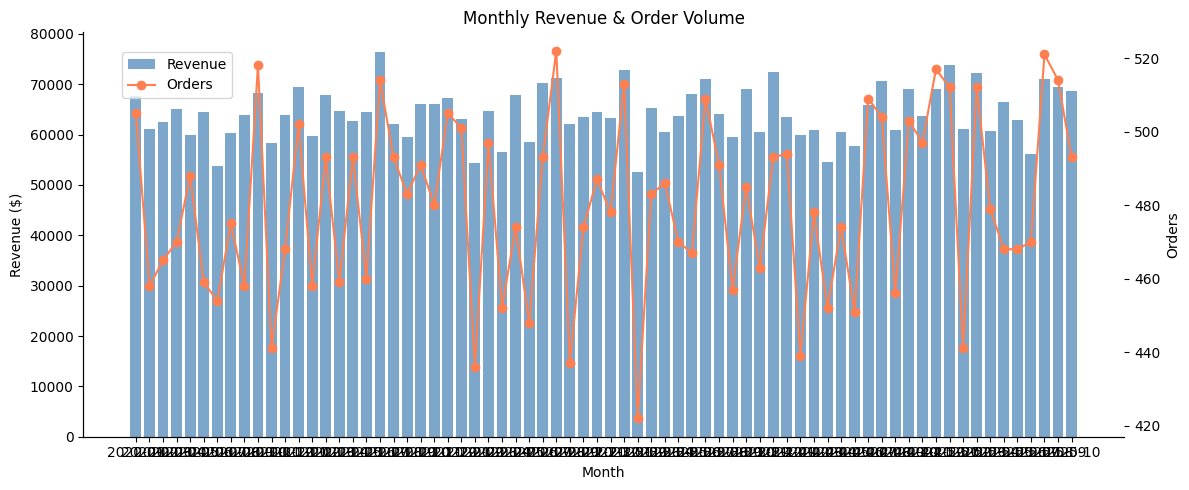

In [6]:
# ============================================================
# SECTION 5 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# ── 5.1 Monthly Revenue Trend ──
orders['month']     = orders['order_time'].dt.to_period('M')
monthly = orders.groupby('month').agg(
    revenue      = ('total_usd', 'sum'),
    total_orders = ('order_id',  'count')
).reset_index()
monthly['month_str'] = monthly['month'].astype(str)

fig, ax1 = plt.subplots()
ax1.bar(monthly['month_str'], monthly['revenue'], color='steelblue', alpha=0.7, label='Revenue')
ax1.set_ylabel('Revenue ($)')
ax1.set_xlabel('Month')
ax2 = ax1.twinx()
ax2.plot(monthly['month_str'], monthly['total_orders'], color='coral', marker='o', label='Orders')
ax2.set_ylabel('Orders')
plt.title('Monthly Revenue & Order Volume')
plt.xticks(rotation=90)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'monthly_revenue.png', dpi=150)
plt.show()


**# INSIGHT:**

 Revenue holds $60K–$70K band. Volume drives revenue; AOV is flat.

 Consistent spikes in Jul/Dec, drops in Feb.

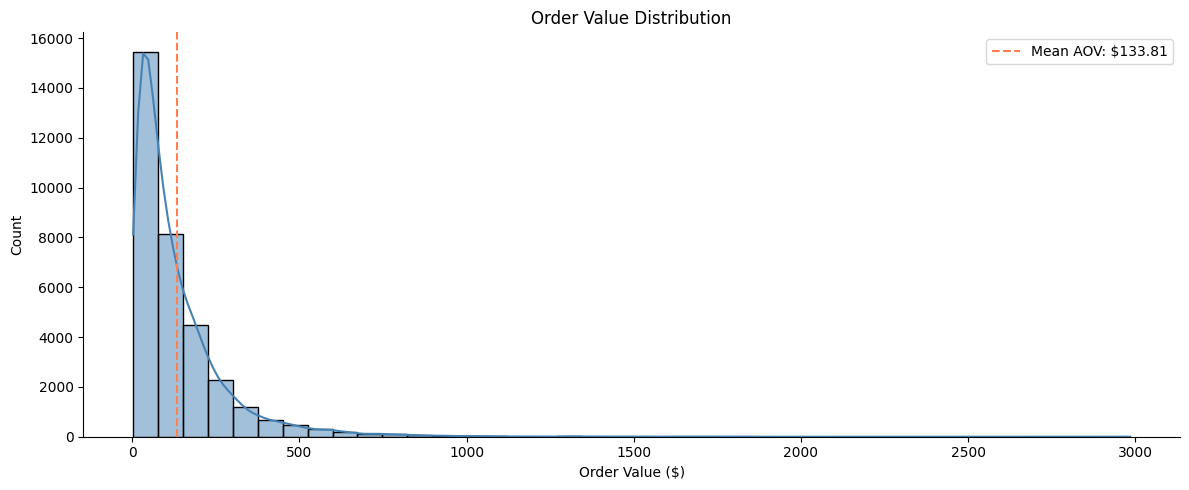

In [7]:
# ── 5.2 AOV Distribution ──
plt.figure()
sns.histplot(orders['total_usd'], bins=40, color='steelblue', kde=True)
plt.axvline(orders['total_usd'].mean(), color='coral', linestyle='--',
            label=f"Mean AOV: ${orders['total_usd'].mean():.2f}")
plt.title('Order Value Distribution')
plt.xlabel('Order Value ($)')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'aov_distribution.png', dpi=150)
plt.show()

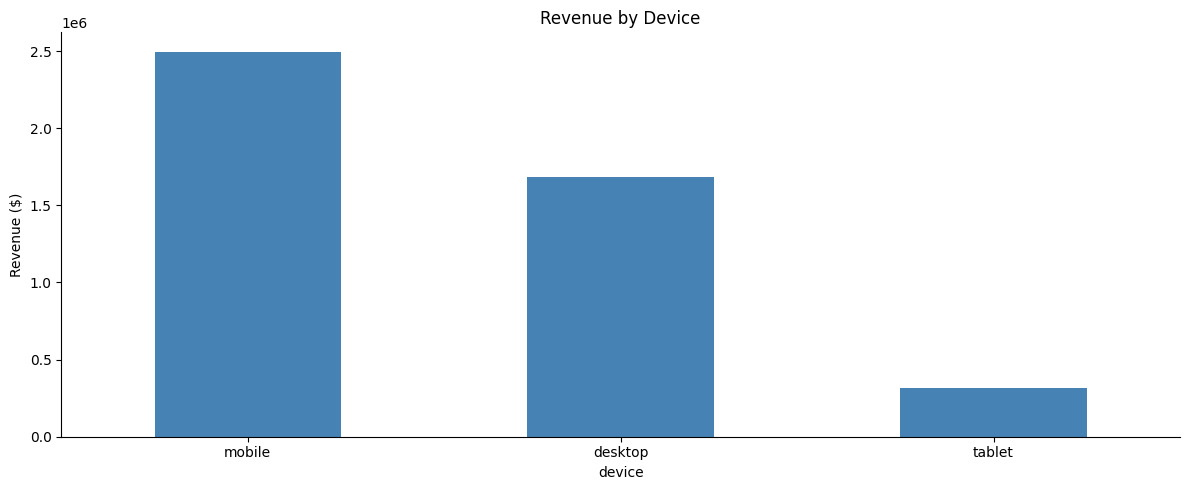

In [8]:
# ── 5.3 Revenue by Device ──
device_rev = orders.groupby('device')['total_usd'].sum().sort_values(ascending=False)
device_rev.plot(kind='bar', color='steelblue', title='Revenue by Device')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'revenue_by_device.png', dpi=150)
plt.show()


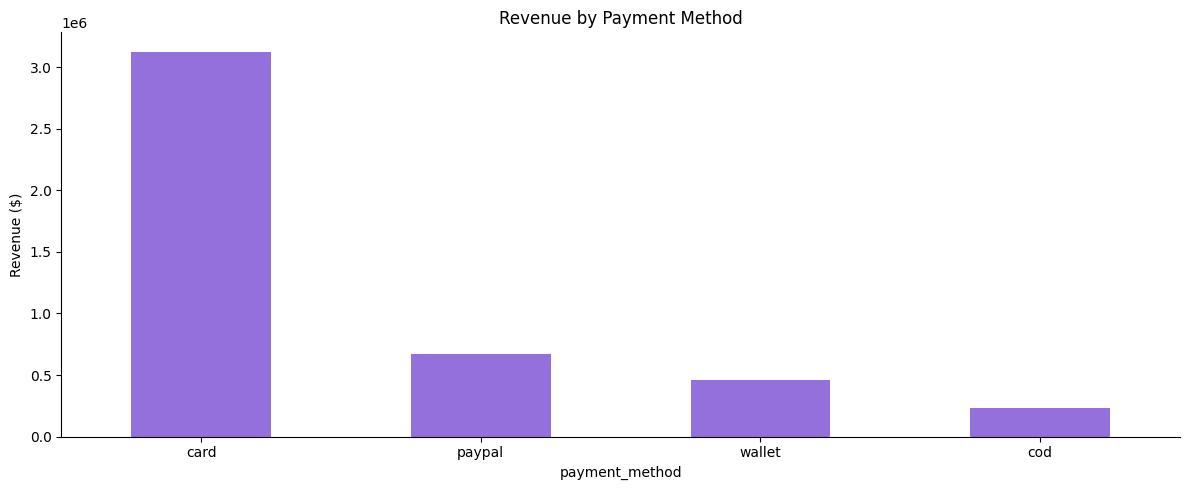

In [9]:
# ── 5.4 Revenue by Payment Method ──
payment_rev = orders.groupby('payment_method')['total_usd'].sum().sort_values(ascending=False)
payment_rev.plot(kind='bar', color='mediumpurple', title='Revenue by Payment Method')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'revenue_by_payment.png', dpi=150)
plt.show()

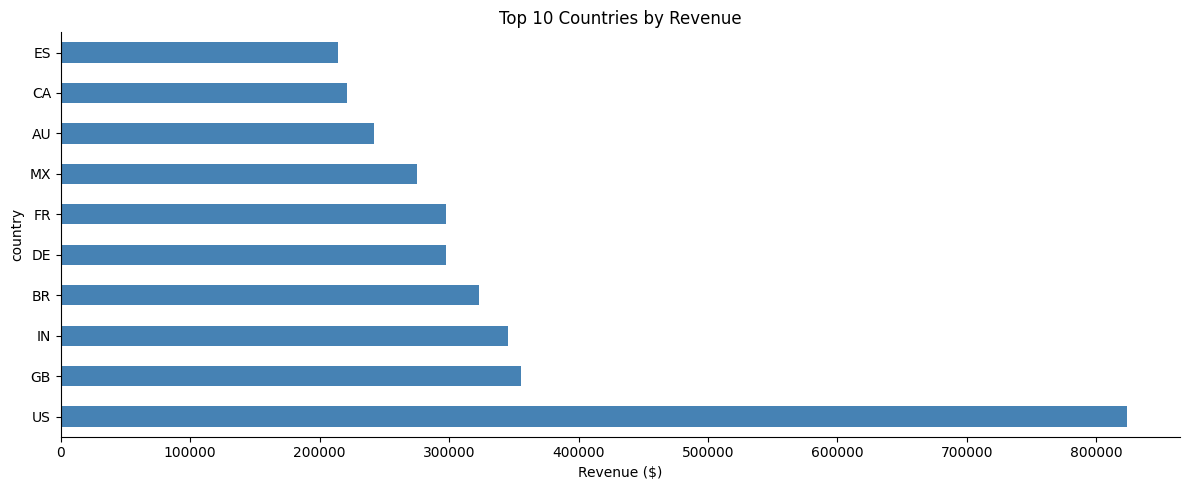

In [10]:
# ── 5.5 Top 10 Countries by Revenue ──
country_rev = orders.groupby('country')['total_usd'].sum().sort_values(ascending=False).head(10)
country_rev.plot(kind='barh', color='steelblue', title='Top 10 Countries by Revenue')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'revenue_by_country.png', dpi=150)
plt.show()

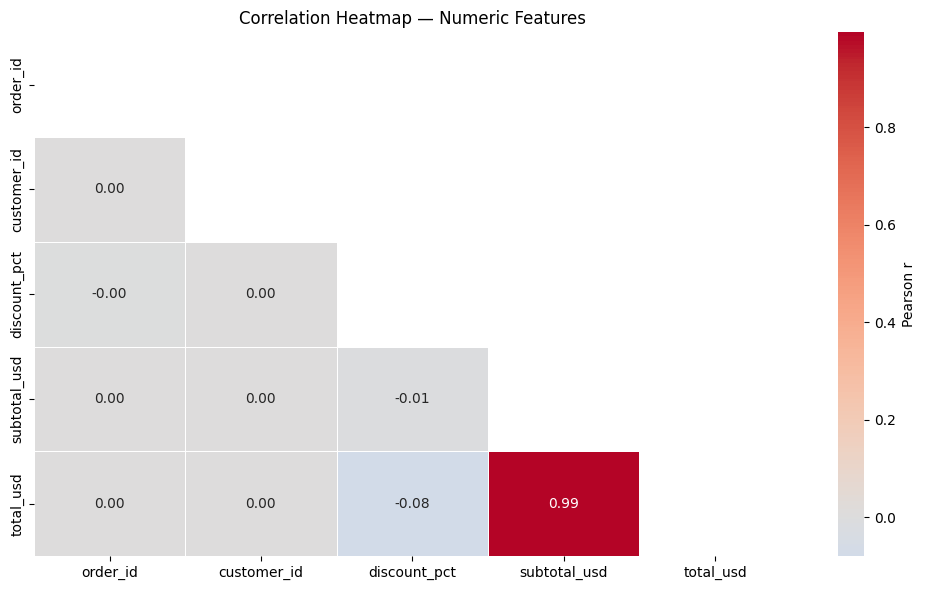

In [11]:
# ── 5.6 Correlation Heatmap ──
# Shows which numeric features move together — key for feature selection

numeric_cols = orders.select_dtypes(include='number').columns.tolist()
corr = orders[numeric_cols].corr()

plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle (redundant)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Pearson r'}
)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

**# INSIGHT:**

 Strong correlations reveal multicollinearity risks for modelling.

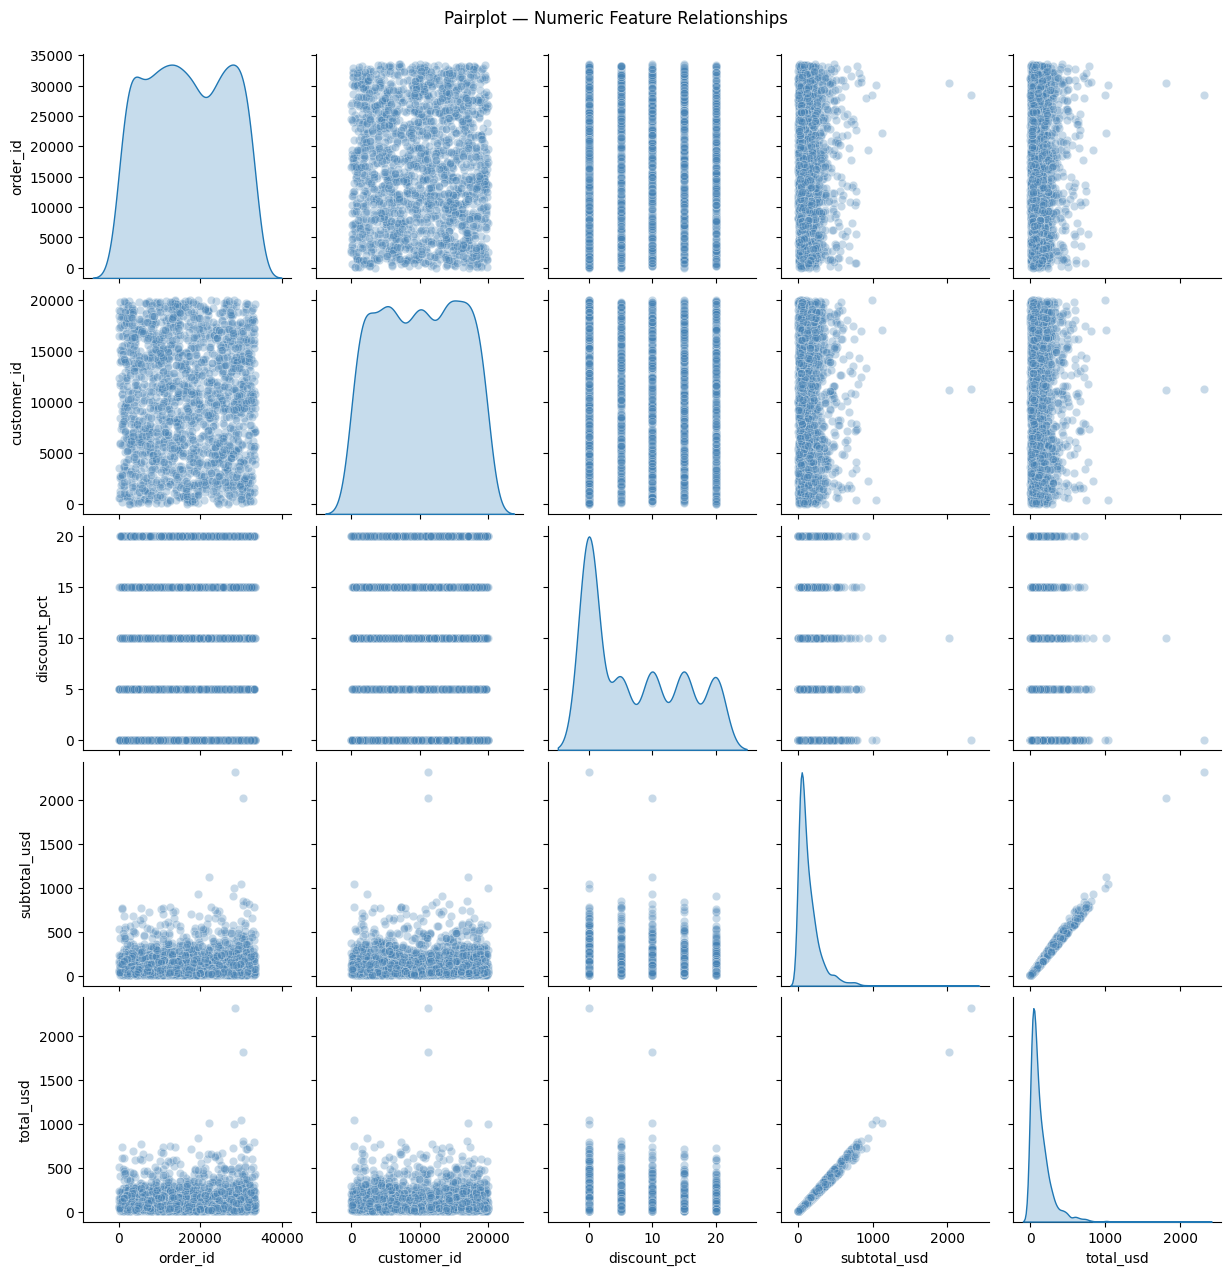

In [12]:
# ── 5.7 Pairplot — Feature Relationships  ──
# Sample for speed on large datasets; shows joint distributions

sample = orders[numeric_cols].sample(min(2000, len(orders)), random_state=42)
sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha': 0.3, 'color': 'steelblue'})
plt.suptitle('Pairplot — Numeric Feature Relationships', y=1.02)
plt.savefig(OUTPUT_DIR / 'pairplot_features.png', dpi=120, bbox_inches='tight')
plt.show()

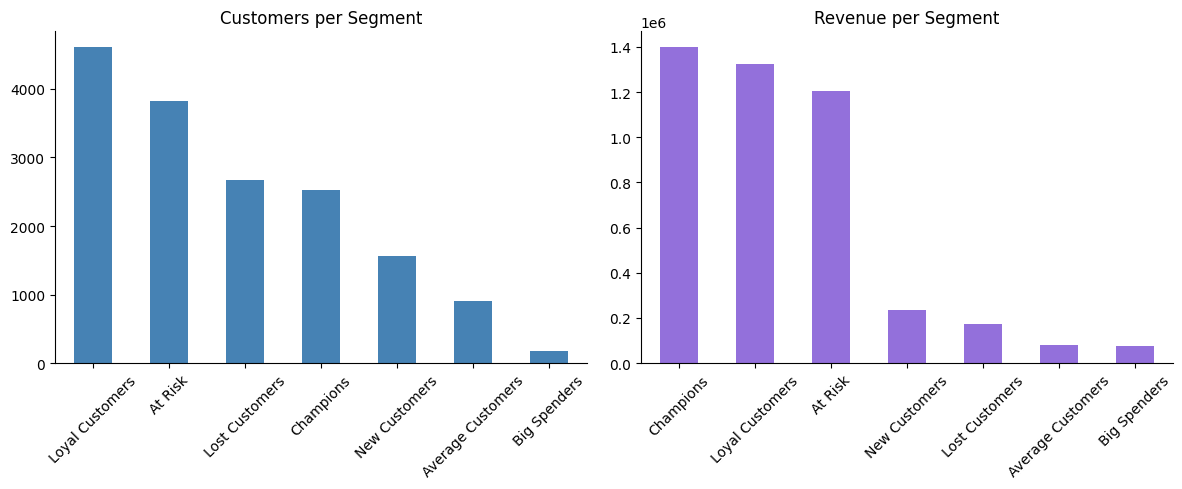


RFM Segment Summary:
                   customers  avg_monetary  avg_recency
segment                                                
Champions               2519        555.33       219.81
Big Spenders             171        441.02       690.01
At Risk                 3823        315.63      1309.98
Loyal Customers         4610        287.27       432.07
New Customers           1556        150.16       242.93
Average Customers        911         90.40       675.37
Lost Customers          2678         64.21      1480.34


In [13]:
# ============================================================
# SECTION 6 — RFM SEGMENTATION
# ============================================================

snapshot_date = orders['order_time'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('customer_id').agg(
    last_purchase = ('order_time', 'max'),
    frequency     = ('order_id',   'count'),
    monetary      = ('total_usd',  'sum')
).reset_index()

rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

rfm['r_score'] = pd.qcut(rfm['recency'],  5, labels=[5, 4, 3, 2, 1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']


def assign_segment(row):
    """
    Priority-ordered rules — first match wins.
    Ordering prevents overlapping conditions from being ambiguous.
    """
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'           # recently active, high freq, high spend
    elif r >= 4 and f <= 2:
        return 'New Customers'       # recent but low frequency — still exploring
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'     # consistent buyers
    elif m >= 4 and r >= 3:
        return 'Big Spenders'        # high monetary, decent recency
    elif r <= 2 and (f >= 3 or m >= 3):
        return 'At Risk'             # historically valuable, going quiet
    elif r <= 2 and f <= 2:
        return 'Lost Customers'      # low engagement, long since purchased
    else:
        return 'Average Customers'


rfm['segment'] = rfm.apply(assign_segment, axis=1)

seg_counts  = rfm['segment'].value_counts()
seg_revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2)
seg_counts.plot(kind='bar',  ax=axes[0], color='steelblue',    title='Customers per Segment')
seg_revenue.plot(kind='bar', ax=axes[1], color='mediumpurple', title='Revenue per Segment')
for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rfm_segments.png', dpi=150)
plt.show()

print('\nRFM Segment Summary:')
print(rfm.groupby('segment').agg(
    customers    = ('customer_id', 'count'),
    avg_monetary = ('monetary',    'mean'),
    avg_recency  = ('recency',     'mean')
).round(2).sort_values('avg_monetary', ascending=False))

**# INSIGHT:**

 Champions — largest segment, highest avg spend, recently active → referral program.

 At Risk   — historically valuable, going quiet → win-back email before day 365.

 Lost      — suppress from paid campaigns, minimal spend.

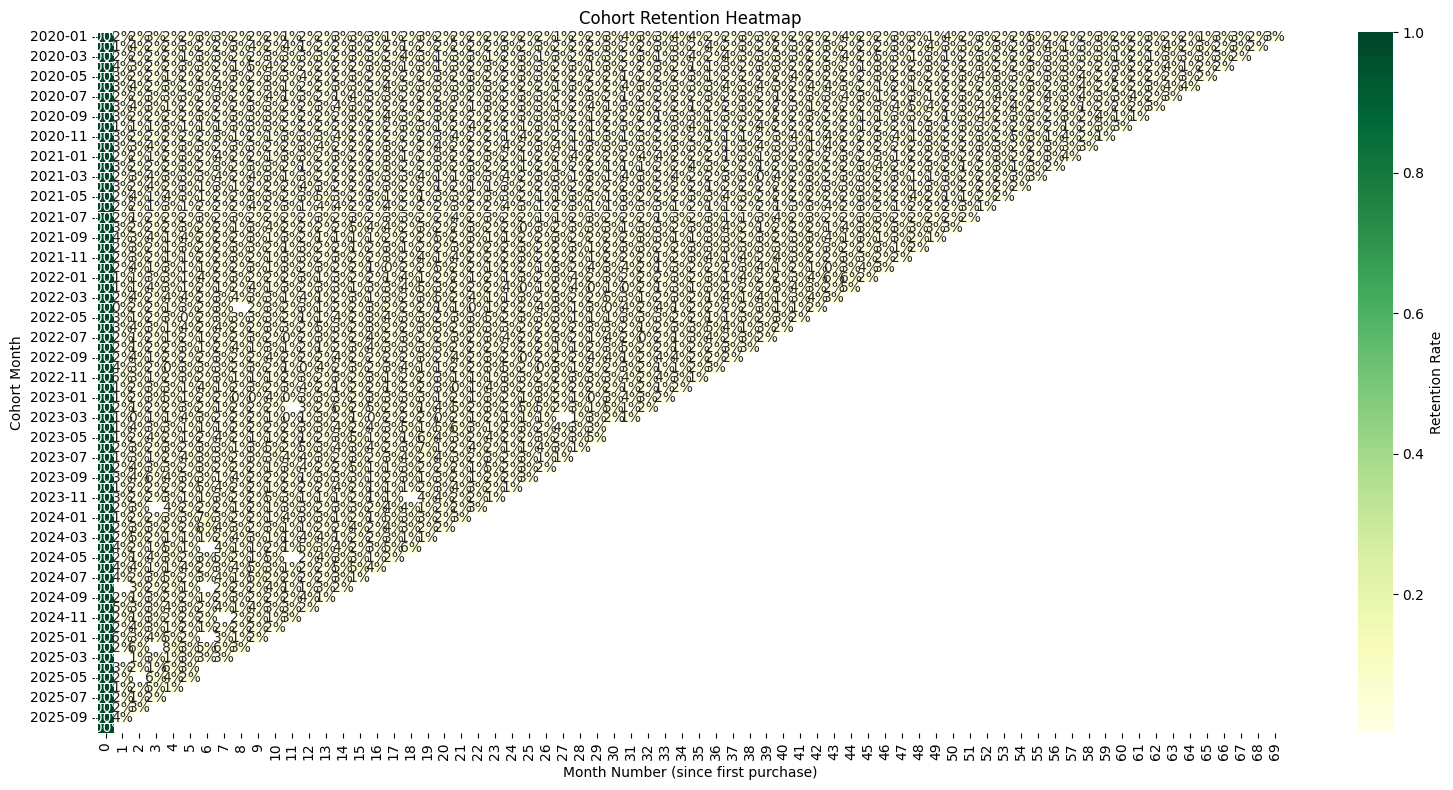

In [14]:
# ============================================================
# SECTION 7 — COHORT RETENTION HEATMAP
# ============================================================

orders['cohort_month'] = (
    orders.groupby('customer_id')['order_time']
    .transform('min')
    .dt.to_period('M')
)
orders['order_month']  = orders['order_time'].dt.to_period('M')
orders['month_number'] = (
    orders['order_month'] - orders['cohort_month']
).apply(lambda x: x.n)

cohort_data = (
    orders.groupby(['cohort_month', 'month_number'])['customer_id']
    .nunique()
    .reset_index()
)
cohort_data.columns = ['cohort_month', 'month_number', 'customers']

cohort_sizes = (
    cohort_data[cohort_data['month_number'] == 0]
    .set_index('cohort_month')['customers']
)
cohort_data['retention_rate'] = cohort_data.apply(
    lambda row: row['customers'] / cohort_sizes[row['cohort_month']], axis=1
)

cohort_pivot = cohort_data.pivot_table(
    index='cohort_month', columns='month_number', values='retention_rate'
)

plt.figure(figsize=(16, 8))
sns.heatmap(
    cohort_pivot,
    annot=True, fmt='.0%',
    cmap='YlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Retention Rate'}
)
plt.title('Cohort Retention Heatmap')
plt.xlabel('Month Number (since first purchase)')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cohort_retention_heatmap.png', dpi=150)
plt.show()

**# INSIGHT:**

 Month-1 retention is only 5–16% across all cohorts.

 Fixing the first-to-second purchase moment is the highest-value retention action.

 NOTE: The white diagonal cells represent 'future' data for newer cohorts that haven't reached that age yet, not missing values.


In [15]:
# ============================================================
# SECTION 8 — CHURN PREDICTION (RANDOM FOREST + PIPELINE)
# ============================================================

max_date = orders['order_time'].max()

churn_base = orders.groupby('customer_id').agg(
    total_orders    = ('order_id',    'count'),
    total_revenue   = ('total_usd',   'sum'),
    avg_order_value = ('total_usd',   'mean'),
    first_purchase  = ('order_time',  'min'),
    last_purchase   = ('order_time',  'max')
).reset_index()

churn_base['recency_days']  = (max_date - churn_base['last_purchase']).dt.days
churn_base['lifespan_days'] = (
    churn_base['last_purchase'] - churn_base['first_purchase']
).dt.days


def label_churn(days):
    """
    Industry-standard thresholds:
      Active   = purchased within 180 days
      At Risk  = 181–365 days since last purchase
      Churned  = more than 365 days since last purchase
    """
    if days <= 180:
        return 'Active'
    elif days <= 365:
        return 'At Risk'
    else:
        return 'Churned'


churn_base['status'] = churn_base['recency_days'].apply(label_churn)

print('\nChurn segment distribution:')
print(churn_base['status'].value_counts())
print('\nRevenue by churn status:')
print(churn_base.groupby('status')['total_revenue'].agg(['sum', 'mean']).round(2))



Churn segment distribution:
status
Churned    11167
Active      2690
At Risk     2411
Name: count, dtype: int64

Revenue by churn status:
                sum    mean
status                     
Active    931384.94  346.24
At Risk   790124.69  327.72
Churned  2771707.84  248.21


In [16]:
# ── Features & labels ──

features = [
    'total_orders',
    'total_revenue',
    'avg_order_value',
    'lifespan_days',
]

X = churn_base[features]
le = LabelEncoder()
y  = le.fit_transform(churn_base['status'])

print(f'\nClass mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # stratify preserves class ratio
)




Class mapping: {'Active': np.int64(0), 'At Risk': np.int64(1), 'Churned': np.int64(2)}


In [17]:
# ── Build Pipeline (scaler + classifier) ──
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',   # FIX: handles class imbalance
        random_state=42,
        n_jobs=-1,
    ))
])
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [18]:
# ── 5-Fold Cross Validation ──
print('\n' + '=' * 50)
print('5-FOLD CROSS VALIDATION')
print('=' * 50)
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='f1_macro', n_jobs=-1)
print(f'F1-macro per fold : {[round(s, 3) for s in cv_scores]}')
print(f'Mean F1-macro     : {cv_scores.mean():.3f}  ±  {cv_scores.std():.3f}')


5-FOLD CROSS VALIDATION
F1-macro per fold : [np.float64(0.435), np.float64(0.432), np.float64(0.438), np.float64(0.424), np.float64(0.449)]
Mean F1-macro     : 0.436  ±  0.008


In [19]:
# ── Hyperparameter Tuning (GridSearchCV) ──
print('\n' + '=' * 50)
print('HYPERPARAMETER TUNING')
print('=' * 50)
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth':    [None, 10, 20],
    'clf__min_samples_split': [2, 5],
}
grid = GridSearchCV(
    pipe, param_grid,
    cv=3, scoring='f1_macro',
    n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)
print(f'Best params : {grid.best_params_}')
print(f'Best CV F1  : {grid.best_score_:.3f}')

best_model = grid.best_estimator_


HYPERPARAMETER TUNING
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params : {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best CV F1  : 0.482


In [20]:
# ── Evaluate on held-out test set ──
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print('\n' + '=' * 50)
print('CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_))



CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Active       0.38      0.25      0.30       538
     At Risk       0.25      0.27      0.26       482
     Churned       0.79      0.84      0.81      2234

    accuracy                           0.66      3254
   macro avg       0.47      0.45      0.46      3254
weighted avg       0.64      0.66      0.65      3254



In [21]:
# ROC-AUC (One-vs-Rest, handles multiclass)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
print(f'ROC-AUC (macro OVR) : {roc_auc:.3f}')


ROC-AUC (macro OVR) : 0.680


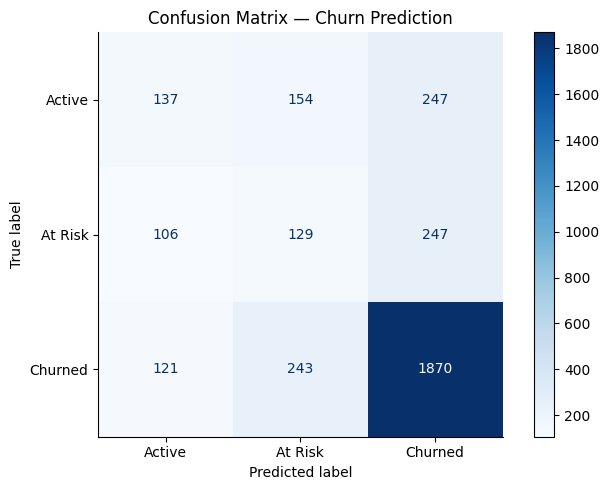

In [22]:
# ── Confusion Matrix Heatmap ──
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Churn Prediction')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

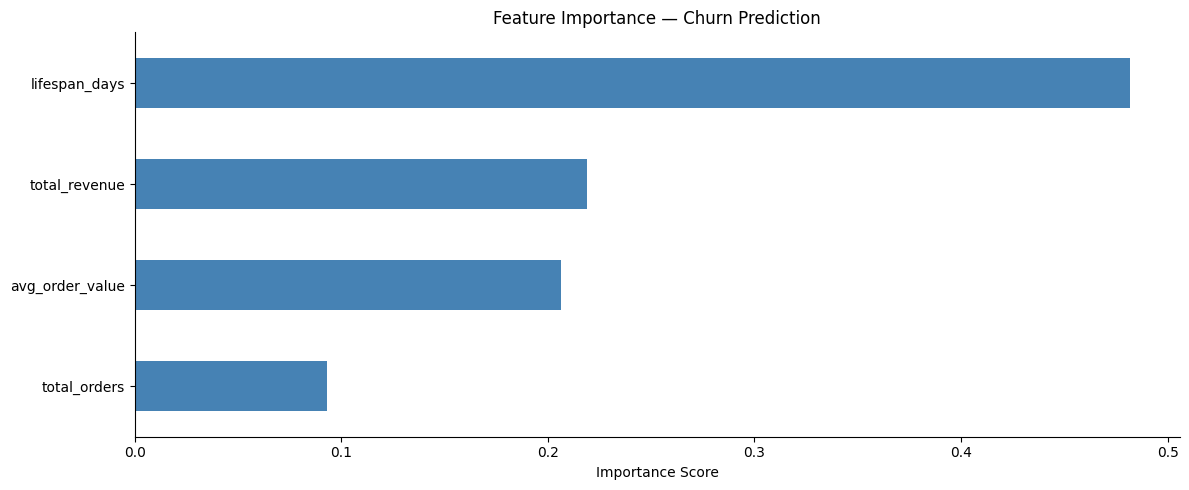

In [23]:
# ── Feature Importance ──
rf         = best_model.named_steps['clf']
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
importance.plot(kind='barh', color='steelblue', title='Feature Importance — Churn Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'churn_feature_importance.png', dpi=150)
plt.show()

In [24]:
# ── Save model ──
model_path = OUTPUT_DIR / 'churn_pipeline.pkl'
joblib.dump(best_model, model_path)
print(f'\n✓ Model saved to {model_path}')



✓ Model saved to /content/outputs/churn_pipeline.pkl


**INSIGHT:**

 recency_days is the strongest predictor of churn.

 At Risk customers hold significant recoverable revenue — target before day 365.

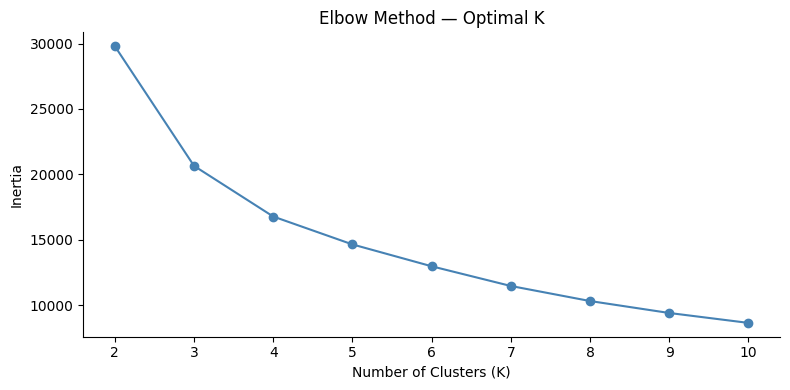

In [25]:
# ============================================================
# SECTION 9 — K-MEANS CUSTOMER CLUSTERING
# ============================================================

cluster_features = ['recency', 'frequency', 'monetary']
X_cluster = rfm[cluster_features].copy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ── Elbow method ──
inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'elbow_method.png', dpi=150)
plt.show()



K-Means Cluster Summary (K=4, chosen from elbow above):
         recency  frequency  monetary
cluster                              
0         466.22       1.55    168.88
1        1491.99       1.33    162.21
2         474.14       3.75    941.23
3         448.55       3.23    373.05

Cluster vs Manual RFM Segment:
segment  At Risk  Average Customers  Big Spenders  Champions  Lost Customers  \
cluster                                                                        
0            502                911           151        197             202   
1           2501                  0             0          0            2476   
2            205                  0            12        684               0   
3            615                  0             8       1638               0   

segment  Loyal Customers  New Customers  
cluster                                  
0                   2569           1524  
1                      0              0  
2                    331          

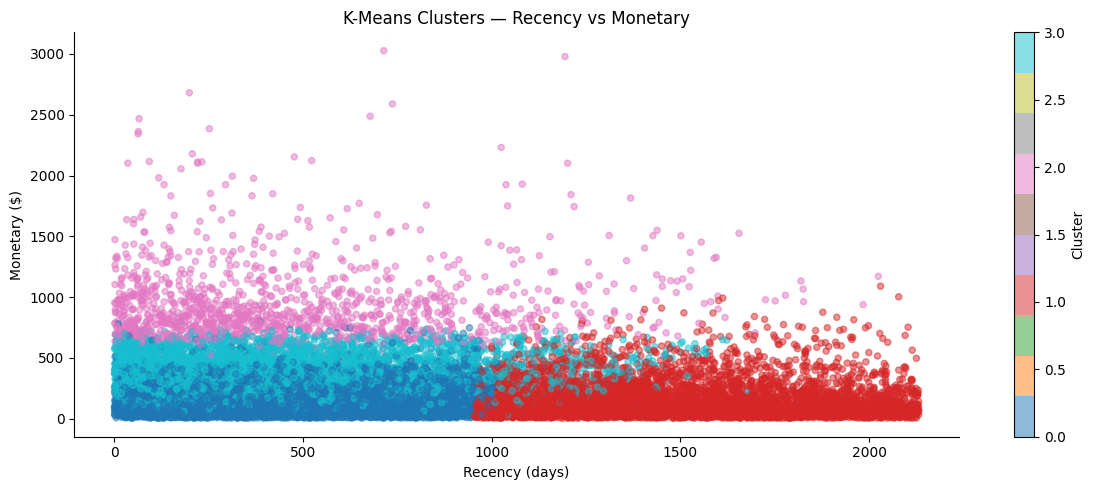

In [26]:
# FIX: K justified by elbow — inertia drop flattens at K=4
K        = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(X_scaled)

print('\nK-Means Cluster Summary (K=4, chosen from elbow above):')
print(rfm.groupby('cluster')[cluster_features].mean().round(2))

print('\nCluster vs Manual RFM Segment:')
print(pd.crosstab(rfm['cluster'], rfm['segment']))

plt.figure()
scatter = plt.scatter(
    rfm['recency'], rfm['monetary'],
    c=rfm['cluster'], cmap='tab10', alpha=0.5, s=20
)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters — Recency vs Monetary')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary ($)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmeans_clusters.png', dpi=150)
plt.show()

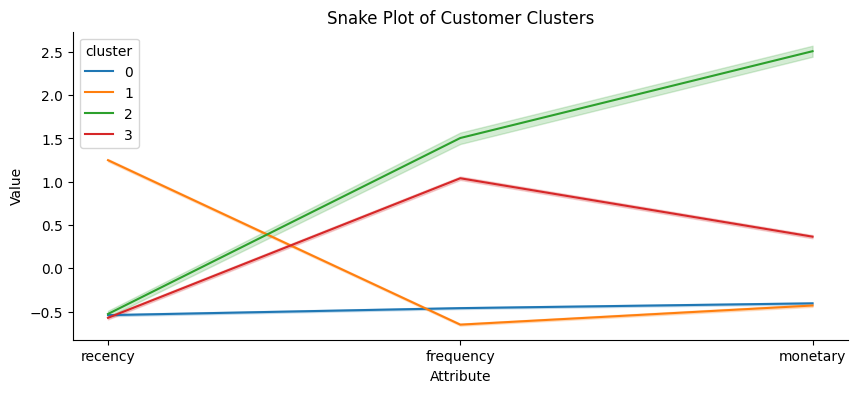

In [27]:
# Melt the data for visualization
rfm_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
rfm_scaled_df['cluster'] = rfm['cluster']
df_melt = pd.melt(rfm_scaled_df, id_vars=['cluster'], var_name='Attribute', value_name='Value')

plt.figure(figsize=(10, 4))
sns.lineplot(x='Attribute', y='Value', hue='cluster', data=df_melt, palette='tab10')
plt.title('Snake Plot of Customer Clusters')
plt.show()

 **INSIGHT: **

 K-Means clusters validate manual RFM segmentation.

 Disagreements reveal nuance the rule-based segment misses.

 Both methods together are stronger than either alone.


In [28]:
# ============================================================
# SECTION 10 — EXPORT SEGMENTED DATA
# ============================================================

final_output = rfm[[
    'customer_id', 'recency', 'frequency', 'monetary',
    'r_score', 'f_score', 'm_score', 'rfm_score',
    'segment', 'cluster'
]].merge(
    churn_base[['customer_id', 'status', 'lifespan_days', 'recency_days']],
    on='customer_id', how='left'
)

out_path = OUTPUT_DIR / 'customer_segments_final.csv'
final_output.to_csv(out_path, index=False)
print(f'\n✓ Exported: {out_path}')
print(f'Shape: {final_output.shape}')
print(final_output.head())


✓ Exported: /content/outputs/customer_segments_final.csv
Shape: (16268, 13)
   customer_id  recency  frequency  monetary  r_score  f_score  m_score  \
0            1      129          2    115.39        5        2        2   
1            2      303          2     68.52        4        2        1   
2            3     1946          1     66.72        1        1        1   
3            4      823          2    279.86        3        2        4   
4            5      275          3    271.29        4        4        4   

   rfm_score         segment  cluster   status  lifespan_days  recency_days  
0          9   New Customers        0   Active           1195           128  
1          7   New Customers        0  At Risk            382           302  
2          3  Lost Customers        1  Churned              0          1945  
3          9    Big Spenders        0  Churned           1035           822  
4         12       Champions        3  At Risk            228           274  


**##  Model Export for Deployment (Streamlit Integration)**

In [29]:
# ================================
# SAVE MODEL FOR STREAMLIT APP
# ================================

import pickle
pickle.dump(pipe, open("model.pkl", "wb"))

print("✅ Model saved successfully as model.pkl")

✅ Model saved successfully as model.pkl


In [30]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# ================================
# FINAL DATASET FOR POWER BI — COMPLETE
# ================================

# Step 1 — Add ML predictions to churn_base
churn_base['prediction'] = pipe.predict(X)

label_map = {0: 'Active', 1: 'At Risk', 2: 'Churned'}
churn_base['customer_segment'] = churn_base['prediction'].map(label_map)

# Step 2 — Add churn probability (0.0 to 1.0)
churn_proba = pipe.predict_proba(X)
churn_base['churn_probability'] = churn_proba.max(axis=1).round(4)

# Step 3 — Merge RFM scores into churn_base
final_dataset = churn_base.merge(
    rfm[['customer_id', 'recency', 'frequency', 'monetary',
         'r_score', 'f_score', 'm_score', 'rfm_score', 'segment']],
    on='customer_id',
    how='left'
)

# Step 4 — Add KMeans cluster
final_dataset = final_dataset.merge(
    rfm[['customer_id']].assign(cluster=
        KMeans(n_clusters=4, random_state=42, n_init=10)
        .fit_predict(
            StandardScaler().fit_transform(
                rfm[['recency','frequency','monetary']]
            )
        )
    ),
    on='customer_id',
    how='left'
)

# Step 5 — Add revenue at risk flag
final_dataset['revenue_at_risk'] = final_dataset.apply(
    lambda x: x['total_revenue'] if x['customer_segment'] == 'At Risk' else 0,
    axis=1
)

# Step 6 — Add engagement tier
final_dataset['engagement_tier'] = pd.cut(
    final_dataset['total_orders'],
    bins=[0, 1, 2, 4, 999],
    labels=['Single Purchase', 'Low Engagement',
            'Regular', 'High Engagement']
)

# Step 7 — Add lifespan category
final_dataset['lifespan_category'] = pd.cut(
    final_dataset['lifespan_days'],
    bins=[-1, 90, 365, 730, 9999],
    labels=['New', 'Growing', 'Established', 'Veteran']
)

# Step 8 — Verify
print("=" * 55)
print("  EXPORT DATASET SUMMARY")
print("=" * 55)
print(f"Total rows     : {len(final_dataset):,}")
print(f"Total columns  : {final_dataset.shape[1]}")
print()
print("Customer segment distribution:")
print(final_dataset['customer_segment'].value_counts())
print()
print("RFM segment distribution:")
print(final_dataset['segment'].value_counts())
print()
print("Engagement tier distribution:")
print(final_dataset['engagement_tier'].value_counts())
print()
print("Columns in export:")
print(list(final_dataset.columns))

# Step 9 — Export
final_dataset.to_csv("final_dataset.csv", index=False)
print("\n✅ Final dataset exported successfully")

from google.colab import files
files.download("final_dataset.csv")

  EXPORT DATASET SUMMARY
Total rows     : 16,268
Total columns  : 24

Customer segment distribution:
customer_segment
Churned    11290
Active      2581
At Risk     2397
Name: count, dtype: int64

RFM segment distribution:
segment
Loyal Customers      4610
At Risk              3823
Lost Customers       2678
Champions            2519
New Customers        1556
Average Customers     911
Big Spenders          171
Name: count, dtype: int64

Engagement tier distribution:
engagement_tier
Single Purchase    6223
Low Engagement     5315
Regular            4154
High Engagement     576
Name: count, dtype: int64

Columns in export:
['customer_id', 'total_orders', 'total_revenue', 'avg_order_value', 'first_purchase', 'last_purchase', 'recency_days', 'lifespan_days', 'status', 'prediction', 'customer_segment', 'churn_probability', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'segment', 'cluster', 'revenue_at_risk', 'engagement_tier', 'lifespan_category']

✅ Final 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

          **BUSINESS RECOMMENDATIONS - ACTION PLANS**

1. WIN-BACK CAMPAIGN — At Risk customers
   ▸ ~3,823 customers with avg $315 spend but silent for 180–365 days
   ▸ Action: personalised email + 10% discount before day 365
   ▸ Estimated recoverable revenue: high — these were real buyers

2. FIRST → SECOND PURCHASE NUDGE
   ▸ Month-1 retention is 5–16% — 84–95% never return after order 1
   ▸ Action: post-purchase email sequence at day 7, 14, 30
   ▸ Even lifting retention to 20% adds ~$133/customer at zero CAC

3. CHAMPIONS REFERRAL PROGRAM
   ▸ 4,417 Champions with highest AOV and recent activity
   ▸ Action: invite to refer a friend — offer reward on friend's first order
   ▸ Lowest-cost acquisition channel; highest LTV cohort

4. SUPPRESS LOST CUSTOMERS FROM PAID CHANNELS
   ▸ 2,678 Lost Customers with avg $64 spend, silent 1,480+ days
   ▸ Action: remove from Google/Meta retargeting audiences
   ▸ Saves ad budget; reallocate to At Risk win-back instead

5. MODEL IN PRODUCTION
   ▸ Re-score customers monthly using churn_pipeline.pkl
   ▸ Flag anyone crossing into At Risk for automated CRM trigger
   ▸ Re-train quarterly as new data accumulates
